# Module 9 - Categorical Data Analysis

Categorical data analysis examines category frequencies, distributions, cardinality, and imbalance.

This notebook uses the Hotel Booking Demand dataset to analyze important categorical variables and their relationship with the target variable.

## 1. Setup and Data Load

The required libraries are imported and the Hotel Booking Demand dataset is loaded for categorical data analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Unique Categories

Unique categories are the distinct values present in a categorical variable.

They help us understand how many different categories are available in a column.

### Example

The hotel column contains categories such as City Hotel and Resort Hotel.

### Real-World Example

A hotel company can identify the different hotel types available in the dataset.

### AI/ML Usage

Knowing the number of categories helps in choosing suitable encoding methods for Machine Learning.

### Implementation

In [2]:
hotel_categories = df["hotel"].unique()

print("Unique Hotel Categories:", hotel_categories)
print("Number of Categories:", df["hotel"].nunique())

Unique Hotel Categories: <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
Number of Categories: 2


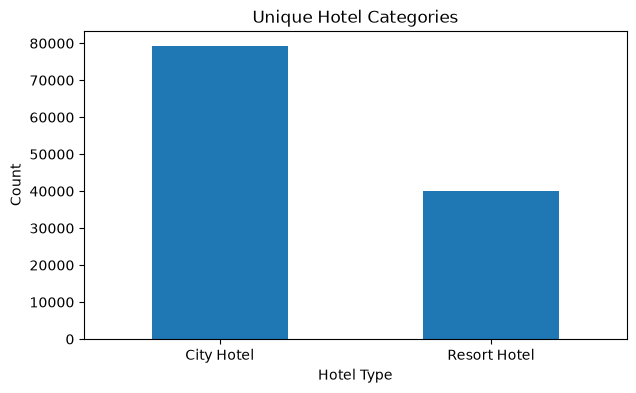

In [3]:
plt.figure(figsize=(7, 4))

df["hotel"].value_counts().plot(kind="bar")

plt.title("Unique Hotel Categories")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Interpretation

The output shows the distinct categories present in each selected categorical variable.

### Insight

Variables with fewer categories are easier to analyze and encode, while variables with many categories may require additional consideration.

## 3. Category Frequencies

Category frequency represents the number of records belonging to each category.

### Example

The frequency of hotel types shows how many bookings belong to City Hotel and Resort Hotel.

### Implementation

In [10]:
categorical_cols = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


hotel
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

meal
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

market_segment
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

deposit_type
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

customer_type
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


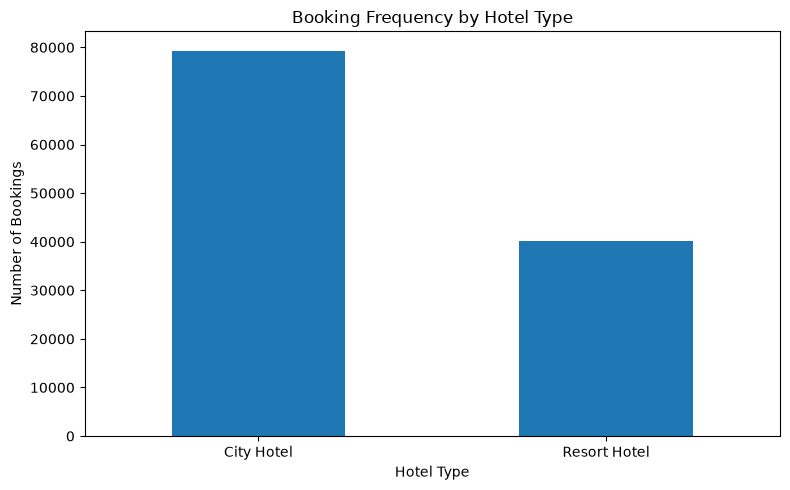

In [5]:
plt.figure(figsize=(8, 5))

df["hotel"].value_counts().plot(kind="bar")

plt.title("Booking Frequency by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The frequency counts show how often each category appears in the dataset.

### Insight

The frequency distribution helps identify the most common and least common categories.

## 4. Category Distribution

Category distribution shows the proportion of observations represented by each category.

### Implementation

In [6]:
hotel_distribution = df["hotel"].value_counts(normalize=True) * 100

print("Hotel Category Distribution (%):")
print(hotel_distribution.round(2))

Hotel Category Distribution (%):
hotel
City Hotel      66.45
Resort Hotel    33.55
Name: proportion, dtype: float64


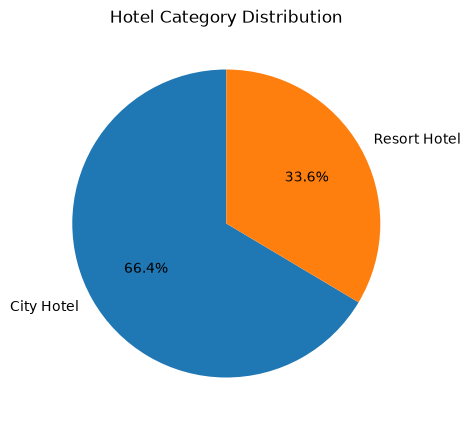

In [7]:
plt.figure(figsize=(7, 5))

df["hotel"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Hotel Category Distribution")
plt.ylabel("")
plt.show()

### Interpretation

The percentage distribution shows the share of total bookings represented by each hotel type.

### Insight

Percentage distribution makes it easier to compare categories based on their proportion of the complete dataset.

## 5. Rare Categories

Rare categories are categories that occur much less frequently than other categories.

They may contain limited information and should be reviewed before Machine Learning.

### Example

A category with a very small number of bookings compared with the total records can be considered rare.

### Implementation

In [12]:
for col in categorical_cols:
    frequency = df[col].value_counts(dropna=False)
    percentage = df[col].value_counts(normalize=True, dropna=False) * 100

    rare_categories = percentage[percentage < 1]

    print(f"\n{col}")
    print("Rare Categories (<1%):")
    print(rare_categories.round(2))


hotel
Rare Categories (<1%):
Series([], Name: proportion, dtype: float64)

meal
Rare Categories (<1%):
meal
Undefined    0.98
FB           0.67
Name: proportion, dtype: float64

market_segment
Rare Categories (<1%):
market_segment
Complementary    0.62
Aviation         0.20
Undefined        0.00
Name: proportion, dtype: float64

distribution_channel
Rare Categories (<1%):
distribution_channel
GDS          0.16
Undefined    0.00
Name: proportion, dtype: float64

deposit_type
Rare Categories (<1%):
deposit_type
Refundable    0.14
Name: proportion, dtype: float64

customer_type
Rare Categories (<1%):
customer_type
Group    0.48
Name: proportion, dtype: float64


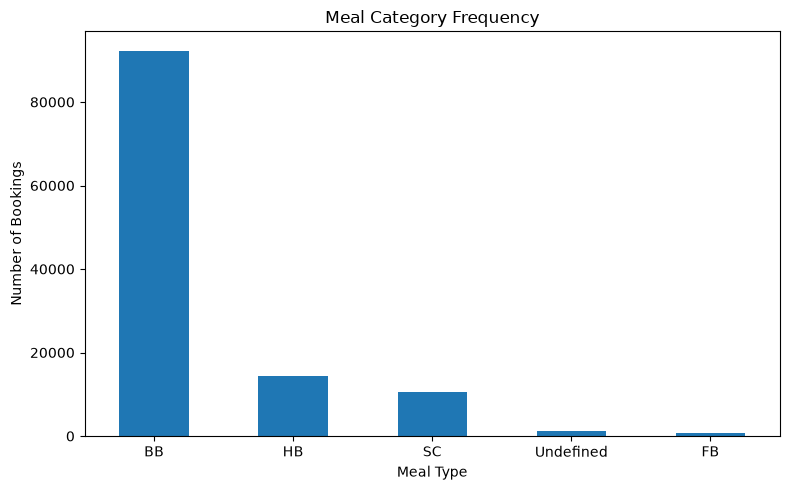

In [13]:
meal_counts = df["meal"].value_counts()

plt.figure(figsize=(8, 5))
meal_counts.plot(kind="bar")

plt.title("Meal Category Frequency")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

Categories representing a very small percentage of records may be considered rare.

### Insight

Rare categories should be reviewed because they may have limited representation in analysis or Machine Learning.

## 6. High Cardinality

High cardinality means a categorical variable contains a large number of unique categories compared with the dataset size.

### Example

An identifier column such as a booking or customer identifier usually has high cardinality.

### Implementation

In [14]:
all_categorical = df.select_dtypes(include="object").columns

cardinality = df[all_categorical].nunique().sort_values(ascending=False)

print("Categorical Variable Cardinality:")
print(cardinality)

Categorical Variable Cardinality:
reservation_status_date    926
country                    177
assigned_room_type          12
arrival_date_month          12
reserved_room_type          10
market_segment               8
distribution_channel         5
meal                         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_24412\1987806844.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_categorical = df.select_dtypes(include="object").columns


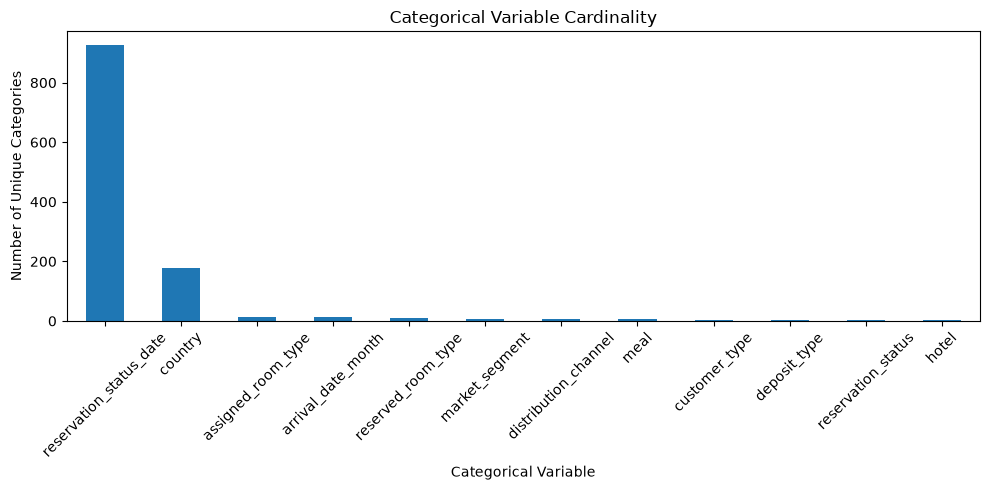

In [16]:
plt.figure(figsize=(10, 5))

cardinality.plot(kind="bar")

plt.title("Categorical Variable Cardinality")
plt.xlabel("Categorical Variable")
plt.ylabel("Number of Unique Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The output shows the number of unique categories in each categorical variable.

### Insight

Columns with a very large number of unique values may be high-cardinality features. Identifier-like columns should generally be treated separately from normal categorical features.

## 7. Low Cardinality

Low cardinality means a categorical variable contains a small number of unique categories.

### Example

The hotel variable has only a small number of hotel categories.

### Implementation

In [17]:
low_cardinality = cardinality[cardinality <= 10]

print("Low Cardinality Variables:")
print(low_cardinality)

Low Cardinality Variables:
reserved_room_type      10
market_segment           8
distribution_channel     5
meal                     5
customer_type            4
deposit_type             3
reservation_status       3
hotel                    2
dtype: int64


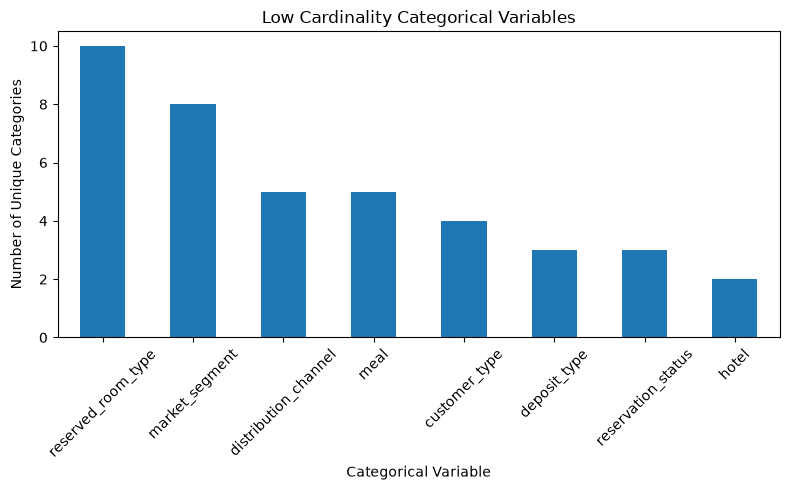

In [18]:
plt.figure(figsize=(8, 5))

low_cardinality.plot(kind="bar")

plt.title("Low Cardinality Categorical Variables")
plt.xlabel("Categorical Variable")
plt.ylabel("Number of Unique Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The output identifies categorical variables with a relatively small number of unique categories.

### Insight

Low-cardinality variables are generally easier to visualize, analyze, and encode.

## 8. Category Imbalance

Category imbalance occurs when some categories contain many more observations than other categories.

### Example

If one category contains most of the bookings while another category contains very few bookings, the variable is imbalanced.

### Implementation

In [19]:
for col in ["hotel", "market_segment", "deposit_type"]:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).mul(100).round(2))


hotel
hotel
City Hotel      66.45
Resort Hotel    33.55
Name: proportion, dtype: float64

market_segment
market_segment
Online TA        47.30
Offline TA/TO    20.29
Groups           16.59
Direct           10.56
Corporate         4.44
Complementary     0.62
Aviation          0.20
Undefined         0.00
Name: proportion, dtype: float64

deposit_type
deposit_type
No Deposit    87.65
Non Refund    12.22
Refundable     0.14
Name: proportion, dtype: float64


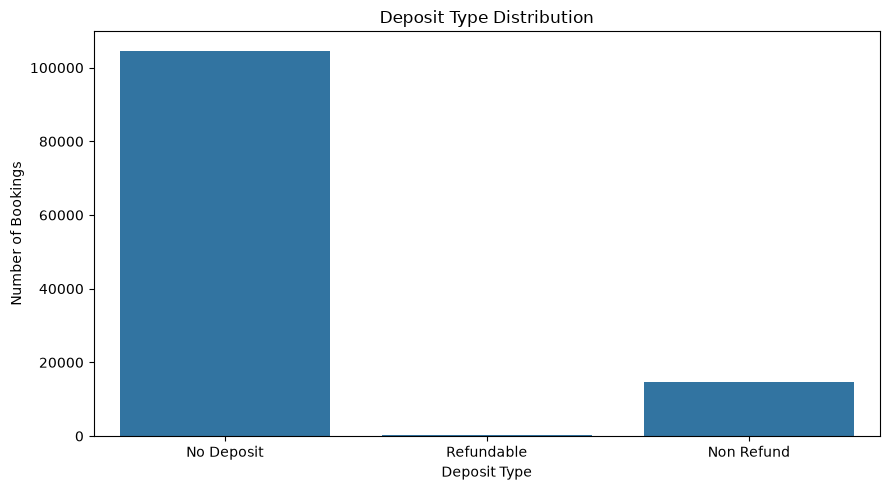

In [20]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="deposit_type")

plt.title("Deposit Type Distribution")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

### Interpretation

The count plot shows the distribution of records across the different deposit categories.

### Insight

A large difference in category frequencies indicates category imbalance, which should be considered during data analysis and Machine Learning.

## 9. Categorical Variables vs Target

The target variable in the Hotel Booking Demand dataset is is_canceled.

Analyzing categorical variables against the target helps understand whether cancellation patterns differ across categories.

### 9.1 Hotel vs Target

### Implementation

In [21]:
hotel_target = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
) * 100

print(hotel_target.round(2))

is_canceled       0      1
hotel                     
City Hotel    58.27  41.73
Resort Hotel  72.24  27.76


### Grouped Bar Chart

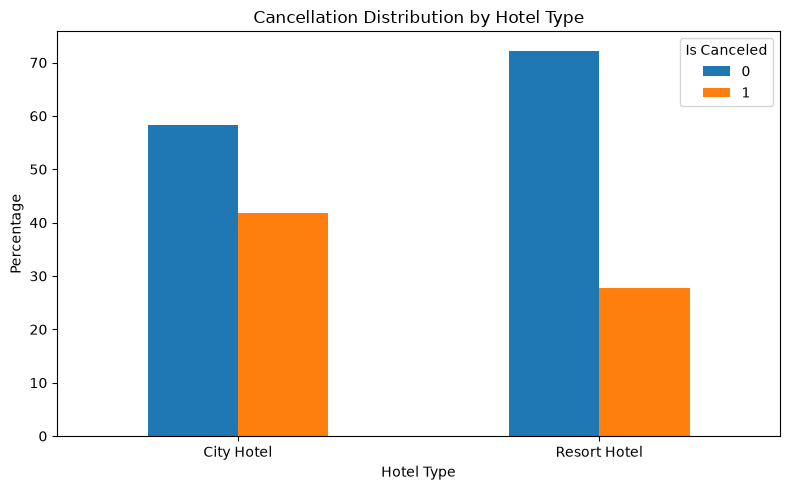

In [22]:
hotel_target.plot(kind="bar", figsize=(8, 5))

plt.title("Cancellation Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Is Canceled")
plt.tight_layout()
plt.show()

### Interpretation

The grouped bar chart compares cancellation percentages across hotel types.

### Insight

The chart helps identify whether the cancellation rate differs between City Hotel and Resort Hotel.

### 9.2 Market Segment vs Target

### Implementation

In [23]:
market_target = pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
) * 100

print(market_target.round(2))

is_canceled         0       1
market_segment               
Aviation        78.06   21.94
Complementary   86.94   13.06
Corporate       81.27   18.73
Direct          84.66   15.34
Groups          38.94   61.06
Offline TA/TO   65.68   34.32
Online TA       63.28   36.72
Undefined        0.00  100.00


### Grouped Bar Chart

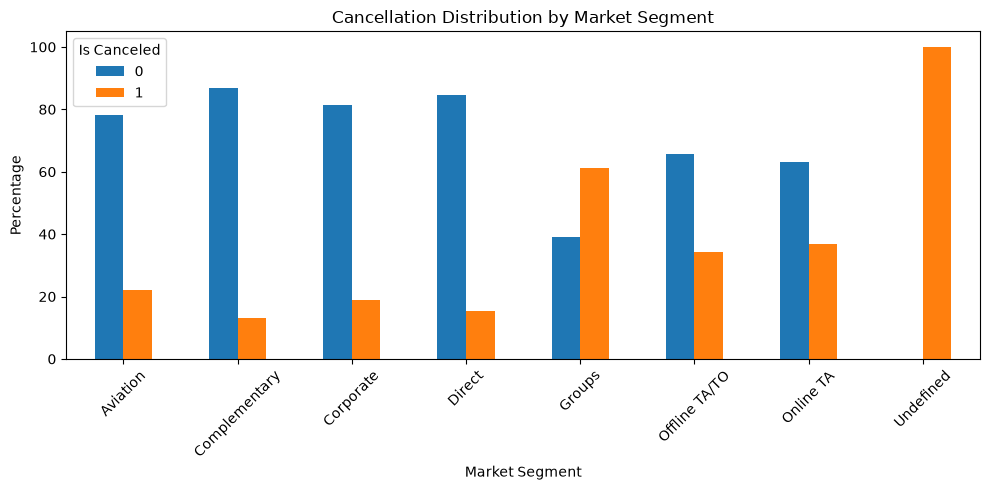

In [24]:
market_target.plot(kind="bar", figsize=(10, 5))

plt.title("Cancellation Distribution by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Is Canceled")
plt.tight_layout()
plt.show()

### Interpretation

The chart compares cancellation percentages across different market segments.

### Insight

This comparison helps identify market segments with relatively higher or lower cancellation rates.

### 9.3 Deposit Type vs Target

### Implementation

In [25]:
deposit_target = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
) * 100

print(deposit_target.round(2))

is_canceled       0      1
deposit_type              
No Deposit    71.62  28.38
Non Refund     0.64  99.36
Refundable    77.78  22.22


### Grouped Bar Chart

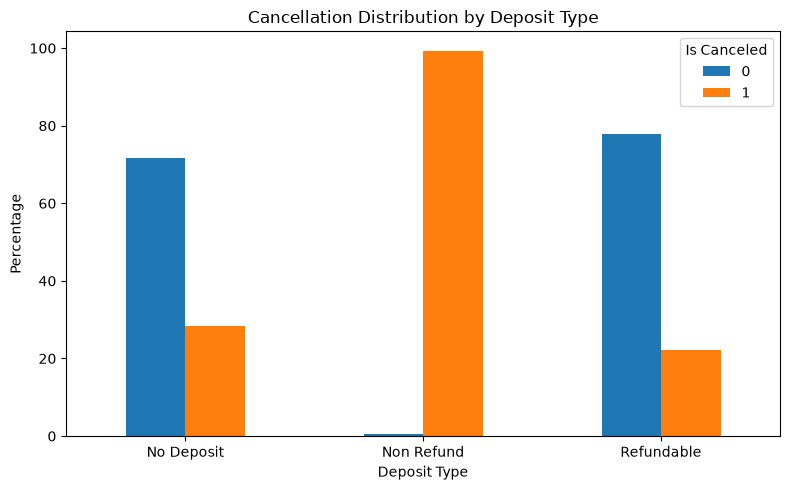

In [26]:
deposit_target.plot(kind="bar", figsize=(8, 5))

plt.title("Cancellation Distribution by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Is Canceled")
plt.tight_layout()
plt.show()

### Interpretation

The chart compares cancellation percentages across different deposit types.

### Insight

The analysis helps identify whether cancellation behavior varies across deposit categories.

## 10. Findings

The categorical analysis identified the unique categories, frequencies, distributions, rare categories, cardinality, and category imbalance of important variables.

The comparison with the target variable helps identify categorical features that may have different cancellation patterns.

These findings provide useful information for categorical feature preprocessing and Machine Learning.